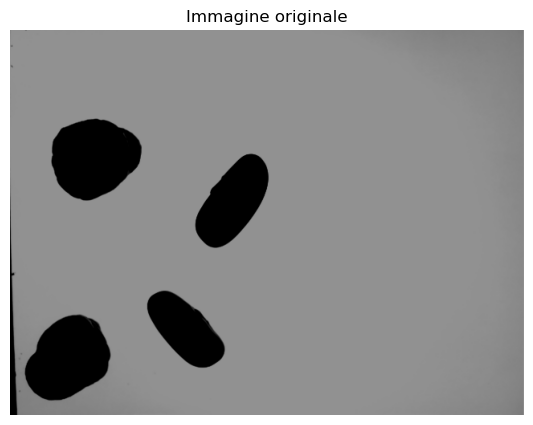

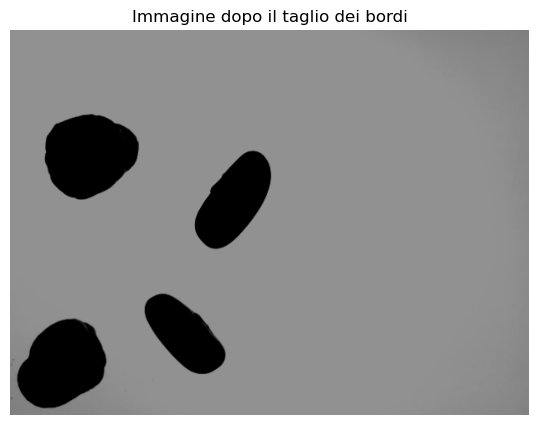

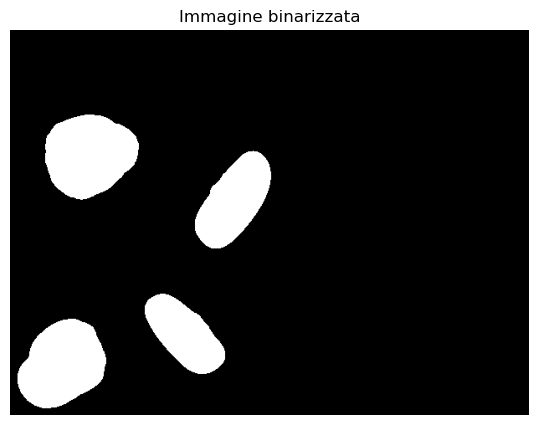

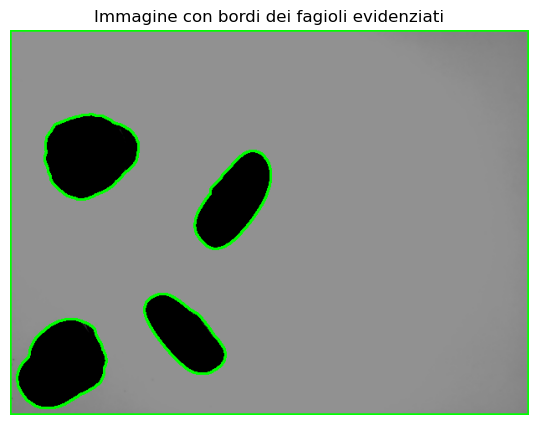

Numero di fagioli rilevati: 4


In [2]:
#%%
import numpy as np  # Importa numpy con alias np
import cv2          # Importa OpenCV
import matplotlib.pyplot as plt  # Importa matplotlib.pyplot con alias plt

# 📌 Carichiamo l'immagine
beans_img = cv2.imread('000006.bmp')
beans_img = cv2.cvtColor(beans_img, cv2.COLOR_BGR2RGB)

# 📌 Mostriamo l'immagine originale
plt.figure(figsize=(10,5))
plt.imshow(beans_img)
plt.title("Immagine originale")
plt.axis('off')
plt.show()

# 📌 Taglio dei bordi
h, w = beans_img.shape[:2]
beans_img_cropped = beans_img[10:h-10, 10:w-10]  # Ritaglio per rimuovere artefatti sui bordi

plt.figure(figsize=(10,5))
plt.imshow(beans_img_cropped)
plt.title("Immagine dopo il taglio dei bordi")
plt.axis('off')
plt.show()

# 📌 Convertiamo in scala di grigi
img_gray = cv2.cvtColor(beans_img_cropped, cv2.COLOR_RGB2GRAY)

# 📌 Binarizzazione con Otsu
_, img_bin = cv2.threshold(img_gray, 75, 255, cv2.THRESH_BINARY_INV) #valutare corretto valore di treshold

plt.figure(figsize=(10,5))
plt.imshow(img_bin, cmap='gray')
plt.title("Immagine binarizzata")
plt.axis('off')
plt.show()

# 📌 Rimozione del rumore con operazioni morfologiche
kernel = np.ones((3,3), np.uint8)
img_opened = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel, iterations=2)

# 📌 Troviamo il Background sicuro
sure_bg = cv2.dilate(img_opened, kernel, iterations=2)

# 📌 Troviamo il Foreground sicuro con Distance Transform
dist_transform = cv2.distanceTransform(img_opened, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# 📌 Troviamo le regioni incerte
unknown = cv2.subtract(sure_bg, sure_fg)

# 📌 Connected-Component Labeling
num_labels, labels = cv2.connectedComponents(sure_fg)

# 📌 Ignoriamo lo sfondo (etichetta 0)
if num_labels == 1:
    num_objects = 0  # Nessun fagiolo rilevato
else:
    num_objects = num_labels - 1  # Escludiamo lo sfondo

# 📌 Disegniamo i contorni con il Watershed
labels = labels + 1
labels[unknown == 255] = 0
beans_img_marked = beans_img_cropped.copy()
cv2.watershed(beans_img_marked, labels)
# Creiamo una maschera dei bordi
borders = (labels == -1).astype(np.uint8) * 255  

# Kernel per aumentare lo spessore dei bordi
kernel = np.ones((3,3), np.uint8)  # Modifica (3,3) per aumentare lo spessore
borders = cv2.dilate(borders, kernel, iterations=1)  # Modifica iterations per più spessore

# Applichiamo il colore del bordo all'immagine
beans_img_marked[borders == 255] = [0, 255, 0]  # Cambia il colore se vuoi


plt.figure(figsize=(10,5))
plt.imshow(beans_img_marked)
plt.title("Immagine con bordi dei fagioli evidenziati")
plt.axis('off')
plt.show()

print(f"Numero di fagioli rilevati: {num_objects}")
